In [3]:
from faker import Faker
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [6]:
fake=Faker()
data=[]
departments = ["Engineering", "HR", "Sales", "Marketing", "Finance"]
for i in range(200):
    experience = random.randint(0, 15)
    se_salary = 30000 + (experience * random.randint(2000, 5000))
    data.append({
        "emp_id": i + 1,
        "department": random.choice(departments),
        "experience_years": experience,
        "salary": se_salary + random.randint(-5000, 5000),
        "performance_score": round(random.uniform(1, 5), 2)
    })
df=pd.DataFrame(data)
df.head()

,emp_id,department,experience_years,salary,performance_score
0,1,HR,12,79942,2.82
1,2,Finance,5,44000,1.23
2,3,HR,15,60826,1.96
3,4,Marketing,2,38122,1.26
4,5,Sales,0,34371,2.40


In [8]:
data_summary=df.groupby('department').agg({
    'salary':['mean','min','max'],
    'performance_score':['mean','min','max']
})
data_summary

salary                performance_score            
                     mean    min     max              mean   min   max
department                                                            
Engineering  52301.452381  26883   90685          3.021429  1.06  4.84
Finance      57480.514286  28426   95508          3.072000  1.13  4.97
HR           56121.914286  28338   80262          3.191714  1.19  4.96
Marketing    55763.043478  27519   90423          2.951304  1.13  4.84
Sales        55723.261905  25585  104091          3.138095  1.11  4.97

In [9]:
def salary_band(salary):
    if salary < 40000:
        return "Low"
    elif salary < 70000:
        return "Medium"
    else:
        return "High"

df["salary_band"] = df["salary"].apply(salary_band)

print(df[["salary", "salary_band"]].head())

   salary salary_band
0   79942        High
1   44000      Medium
2   60826      Medium
3   38122         Low
4   34371         Low


In [10]:
df["exp_norm"] = (df["experience_years"] - df["experience_years"].min()) / (
    df["experience_years"].max() - df["experience_years"].min()
)

df["salary_norm"] = (df["salary"] - df["salary"].min()) / (
    df["salary"].max() - df["salary"].min()
)

df["perf_norm"] = (df["performance_score"] - df["performance_score"].min()) / (
    df["performance_score"].max() - df["performance_score"].min()
)

In [11]:
correlation = np.corrcoef(df["salary"], df["performance_score"])[0, 1]

print("Correlation (Salary vs Performance):", correlation)

Correlation (Salary vs Performance): 0.06011535153298412


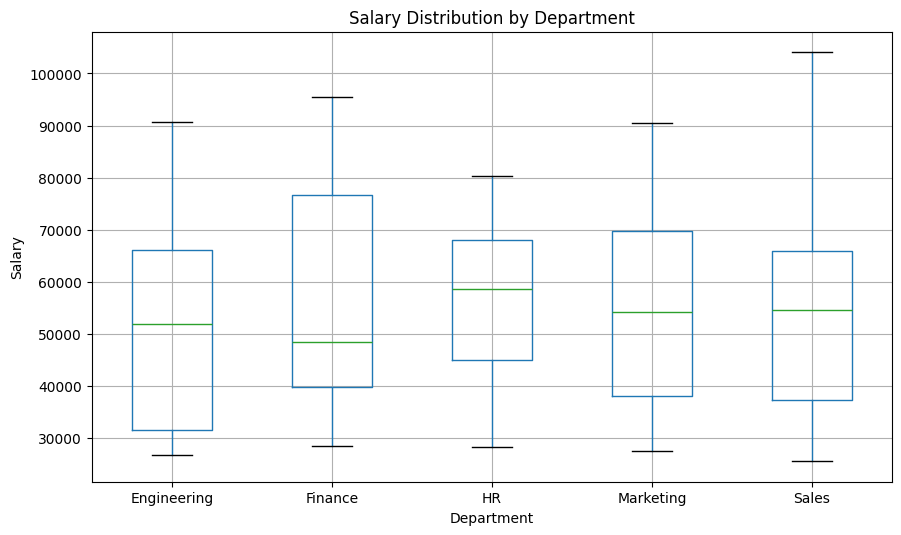

In [12]:
df.boxplot(column="salary", by="department", figsize=(10, 6))

plt.title("Salary Distribution by Department")
plt.suptitle("")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()

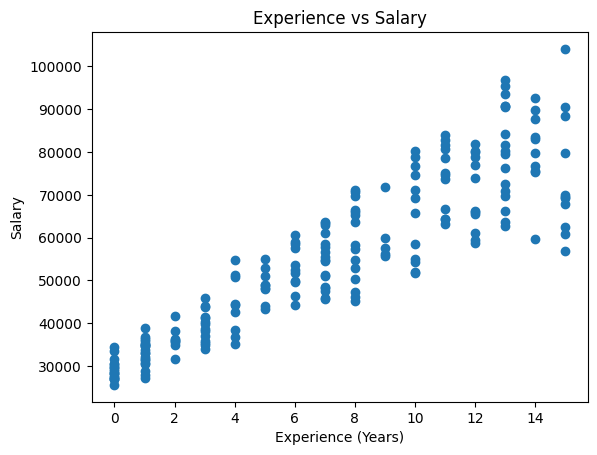

In [13]:
plt.scatter(df["experience_years"], df["salary"])

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

plt.show()